In [12]:
import numpy as np
import pandas as pd
import sys
from tqdm.notebook import tqdm

from scipy.linalg import eig
from scipy.sparse.linalg import eigsh
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix
from scipy.signal import find_peaks

from matplotlib.backends.backend_pdf import PdfPages

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plots = {}

In [13]:
def update_pdf(filename="plots.pdf"):
    with PdfPages(filename) as pdf:
        for key in sorted(plots.keys()):
            pdf.savefig(plots[key])
    print(f"Updated {filename} with {len(plots)} page(s).")

### 1. Geometry and Mesh Generation
Defines the geometric parameters of the plate and generates a structured quadrilateral mesh. The domain is discretized into nodes containing $[x, y]$ physical coordinates, and cell connectivity is established to define 4-node elements.

In [ ]:
cr = 0.19
ct = 0.055
b = 0.065
sw_l = 0.15
t = 0.001

nu = 0.35
E = 70e9
rho = 1800
kappa = 5 / 6

nx = 31
ny = 31
modes = 6

res_fl = 200
res_alt = 200

def Beta(M):
    return np.sqrt(M**2 - 1)

def camber_line(xc):
    return 0 * xc
    #return 0.05*np.exp(-30 * (xc-0.5)**2)
    #return (xc - xc**2)/10
    #return 0

In [16]:
nodes = []
y_vals = np.linspace(0, b, ny)
for y in y_vals:
    x_le = y * (sw_l / b)
    c_local = cr - (y / b) * (cr - ct)
    x_te = x_le + c_local
    x_vals = np.linspace(x_le, x_te, nx)
    for x in x_vals:
        xc = (x - x_le) / c_local
        z = c_local * camber_line(xc)
        nodes.append([x, y, z])

nodes = np.array(nodes)
N = len(nodes)

cells = []
for i in range(ny - 1):
    for j in range(nx - 1):
        n1 = i * nx + j
        n2 = n1 + 1
        n3 = (i + 1) * nx + j
        n4 = n3 + 1
        cells.append([n1, n2, n4, n3])

cells = np.array(cells)

AR = []
for cell in cells:
    n1, n2, n4, n3 = nodes[cell]
    
    s1 = np.linalg.norm(n2 - n1)
    s2 = np.linalg.norm(n4 - n2)
    s3 = np.linalg.norm(n3 - n4)
    s4 = np.linalg.norm(n1 - n3)
    
    sides = [s1, s2, s3, s4]
    AR.append(max(sides) / min(sides))

AR = np.array(AR)

Updated plots.pdf with 1 page(s).


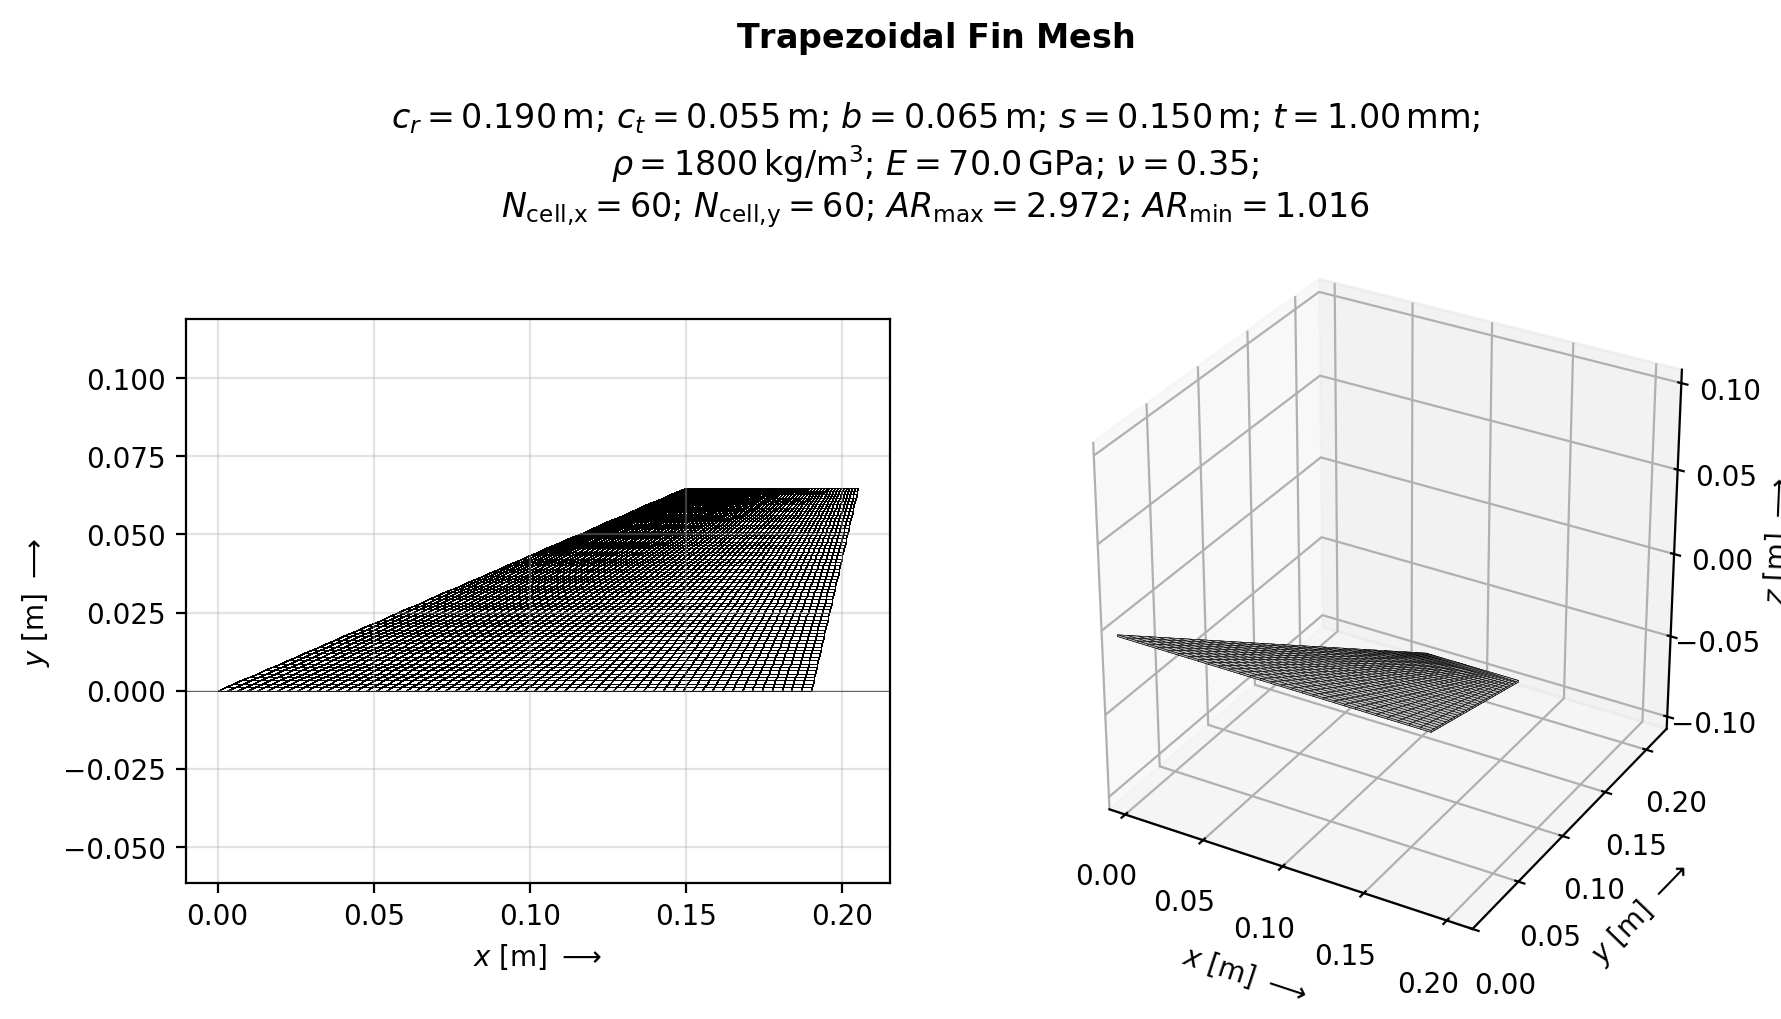

In [17]:
x_max = max(cr, sw_l + ct)
pr = max(x_max, b)
xs = (x_max - b) / 2 if pr == b else 0
margin = 0.05

fig = plt.figure(figsize=(10, 6), dpi=200)
fig.suptitle(f'$\\bf{{Trapezoidal\\,\\,Fin\\,\\,Mesh}}$\n\n$c_r={cr:.3f}\\,$m; $c_t={ct:.3f}\\,$m; $b={b:.3f}\\,$m; $s={sw_l:.3f}\\,$m; $t={t*1e3:.2f}\\,$mm;\n$\\rho={rho:.0f}\\,$kg/m$^3$; $E={E/1e9:.1f}\\,$GPa; $\\nu={nu}$;\n$N_\\text{{cell,x}}={nx-1}$; $N_\\text{{cell,y}}={ny-1}$; $AR_\\text{{max}}={np.max(AR):.3f}$; $AR_\\text{{min}}={np.min(AR):.3f}$')

X, Y, Z = (nodes[:, i].reshape((ny, nx)) for i in range(3))

ax1 = fig.add_subplot(121)
ax1.pcolormesh(X, Y, np.zeros((ny-1, nx-1)), facecolor='none', edgecolor='k', linewidth=0.2)
ax1.axhline(0, color='k', linewidth=0.2)
ax1.grid(True, alpha=0.35)

ax1.set(
    xlabel='$x$ [m] $\\longrightarrow$',
    ylabel='$y$ [m] $\\longrightarrow$',
    xlim=(-margin * x_max + xs, (1+margin) * pr + xs),
    ylim=((1+2*margin)*0.8*(b-pr)/2, (1+2*margin)*0.8*(b+pr)/2),
    box_aspect=0.8
)

ax2 = fig.add_subplot(122, projection='3d')
is_flat = np.allclose(Z, 0, atol=1e-8)
norm = mcolors.Normalize(vmin=Z.min(), vmax=Z.max())
skwargs = {'edgecolor': 'k', 'linewidth': 0.2, 'shade': False, **({'color': 'silver'} if is_flat else {'facecolors': cm.jet(norm(Z))})}

ax2.plot_surface(X, Y, Z + t/2, **skwargs)
ax2.plot_surface(X, Y, Z - t/2, **skwargs)

for x_e, y_e, z_e in [(X[0,:], Y[0,:], Z[0,:]), (X[-1,:], Y[-1,:], Z[-1,:]), (X[:,0], Y[:,0], Z[:,0]), (X[:,-1], Y[:,-1], Z[:,-1])]:
    e_kw = {'color': 'silver'} if is_flat else {'facecolors': cm.jet(norm(np.vstack([z_e, z_e])))}
    ax2.plot_surface(np.vstack([x_e, x_e]), np.vstack([y_e, y_e]), np.vstack([z_e - t/2, z_e + t/2]), edgecolor='k', linewidth=0.2, shade=False, **e_kw)

ax2.set(
    xlabel='$x$ [m] $\\longrightarrow$',
    ylabel='$y$ [m] $\\longrightarrow$',
    zlabel='$z$ [m] $\\longrightarrow$',
    xlim=(-margin * x_max + xs, (1+margin) * pr + xs),
    ylim=(0, (1+2*margin) * pr),
    zlim=(-(1+margin)*pr/2, (1+margin)*pr/2),
    box_aspect=(1, 1, 1)
)

plots['1-grid'] = plt.gcf()
update_pdf()

plt.show()

### 2. Constitutive Matrices
Establishes the material stiffness matrices based on Mindlin-Reissner plate theory. $\mathbf{D}_{mat}$ defines the bending rigidity relating curvatures to moments, while $\mathbf{G}_{mat}$ defines the transverse shear stiffness using a shear correction factor of $\kappa = 5/6$.

$$D=\frac{Et^3}{12\left(1-\nu^2\right)} \qquad [D_{mat}] = D \begin{bmatrix} 1 & \nu & 0 \\ \nu & 1 & 0 \\ 0 & 0 & \frac{1-\nu}{2} \end{bmatrix}$$

$$G = \frac{E}{2(1+\nu)} \qquad [G_{mat}] = \kappa G t \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

In [18]:
D = (E * t**3) / (12 * (1 - nu**2))
D_mat = D * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1-nu)/2]
])

G = E / (2 * (1 + nu))
G_mat = kappa * G * t * np.array([
    [1, 0],
    [0, 1]
])

A_mem = (E * t) / (1 - nu**2) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1-nu)/2]
])

K = np.zeros((5*N, 5*N))
M = np.zeros((5*N, 5*N))

### 3. Numerical Integration Setup
Defines the Gauss quadrature points and weights for Selective Reduced Integration (SRI). A $2 \times 2$ rule is used for bending and mass matrices to prevent zero-energy modes, while a $1 \times 1$ rule is used for the shear matrix to prevent shear locking. The shape functions ($\mathbf{N}$) and their natural derivatives are also established.

In [19]:
pts_2x2 = np.array([
    [-1/np.sqrt(3), -1/np.sqrt(3)],
    [ 1/np.sqrt(3), -1/np.sqrt(3)],
    [ 1/np.sqrt(3),  1/np.sqrt(3)],
    [-1/np.sqrt(3),  1/np.sqrt(3)]
])
w_2x2 = np.array([1, 1, 1, 1])

pts_1x1 = np.array([[0.0, 0.0]])
w_1x1 = np.array([4.0])

def get_dN_nat(xi, eta):
    dN_dxi = np.array([
        -0.25 * (1 - eta),  0.25 * (1 - eta),
         0.25 * (1 + eta), -0.25 * (1 + eta)
    ])
    dN_deta = np.array([
        -0.25 * (1 - xi), -0.25 * (1 + xi),
         0.25 * (1 + xi),  0.25 * (1 - xi)
    ])
    return np.vstack((dN_dxi, dN_deta))

def get_N(xi, eta):
    return np.array([
        0.25 * (1 - xi) * (1 - eta),
        0.25 * (1 + xi) * (1 - eta),
        0.25 * (1 + xi) * (1 + eta),
        0.25 * (1 - xi) * (1 + eta)
    ])

rho_t = rho * t
rho_I = rho * t**3 / 12

### 4. Finite Element Matrix Assembly
Loops through each element to construct local stiffness ($\mathbf{K}_e$) and mass ($\mathbf{M}_e$) matrices. The physical cell coordinates are mapped to the reference element using the Jacobian matrix ($\mathbf{J}$). Strain-displacement matrices ($\mathbf{B}_b$ and $\mathbf{B}_s$) are evaluated, integrated, and scattered into the global system matrices $\mathbf{K}$ and $\mathbf{M}$.

In [20]:
for cell in tqdm(cells, desc="Assembling K, M", unit="elem"):
    coords_3d = nodes[cell]  # (4, 3)

    # Local coordinate system from element center
    dN_c = get_dN_nat(0, 0)
    t1 = dN_c[0, :] @ coords_3d
    t2 = dN_c[1, :] @ coords_3d
    n_vec = np.cross(t1, t2)
    n_vec /= np.linalg.norm(n_vec)
    e1 = t1 / np.linalg.norm(t1)
    e2 = np.cross(n_vec, e1)

    # Project nodes to local 2D
    centroid = np.mean(coords_3d, axis=0)
    coords_local = np.zeros((4, 2))
    for i in range(4):
        dr = coords_3d[i] - centroid
        coords_local[i, 0] = dr @ e1
        coords_local[i, 1] = dr @ e2

    # Transformation matrix (local DOFs → global DOFs)
    R3 = np.array([e1, e2, n_vec])           # 3×3
    R2 = R3[:2, :2]                           # 2×2 for rotations (θx, θy → θ1, θ2)
    T_node = np.block([
        [R3,               np.zeros((3, 2))],
        [np.zeros((2, 3)), R2              ]
    ])
    T_elem = np.zeros((20, 20))
    for i in range(4):
        T_elem[5*i:5*i+5, 5*i:5*i+5] = T_node

    Ke = np.zeros((20, 20))
    Me = np.zeros((20, 20))

    # Full integration: membrane + bending + mass
    for pt, w_val in zip(pts_2x2, w_2x2):
        xi, eta = pt
        N_shape = get_N(xi, eta)
        dN_nat = get_dN_nat(xi, eta)

        J = dN_nat @ coords_local
        detJ = np.linalg.det(J)
        dN_phys = np.linalg.inv(J) @ dN_nat

        # Membrane B-matrix (3×20)
        Bm = np.zeros((3, 20))
        for i in range(4):
            Bm[0, 5*i]   = dN_phys[0, i]
            Bm[1, 5*i+1] = dN_phys[1, i]
            Bm[2, 5*i]   = dN_phys[1, i]
            Bm[2, 5*i+1] = dN_phys[0, i]

        # Bending B-matrix (3×20)
        Bb = np.zeros((3, 20))
        for i in range(4):
            Bb[0, 5*i+3] = dN_phys[0, i]
            Bb[1, 5*i+4] = dN_phys[1, i]
            Bb[2, 5*i+3] = dN_phys[1, i]
            Bb[2, 5*i+4] = dN_phys[0, i]

        Ke += Bm.T @ A_mem @ Bm * detJ * w_val
        Ke += Bb.T @ D_mat @ Bb * detJ * w_val

        # Mass matrix
        Nm = np.zeros((5, 20))
        for i in range(4):
            Nm[0, 5*i]   = N_shape[i]
            Nm[1, 5*i+1] = N_shape[i]
            Nm[2, 5*i+2] = N_shape[i]
            Nm[3, 5*i+3] = N_shape[i]
            Nm[4, 5*i+4] = N_shape[i]

        m5 = np.diag([rho_t, rho_t, rho_t, rho_I, rho_I])
        Me += Nm.T @ m5 @ Nm * detJ * w_val

    # Reduced integration: shear
    for pt, w_val in zip(pts_1x1, w_1x1):
        xi, eta = pt
        N_shape = get_N(xi, eta)
        dN_nat = get_dN_nat(xi, eta)

        J = dN_nat @ coords_local
        detJ = np.linalg.det(J)
        dN_phys = np.linalg.inv(J) @ dN_nat

        Bs = np.zeros((2, 20))
        for i in range(4):
            Bs[0, 5*i+2] = dN_phys[0, i]
            Bs[0, 5*i+3] = -N_shape[i]
            Bs[1, 5*i+2] = dN_phys[1, i]
            Bs[1, 5*i+4] = -N_shape[i]

        Ke += Bs.T @ G_mat @ Bs * detJ * w_val

    # Transform local → global
    Ke_g = T_elem.T @ Ke @ T_elem
    Me_g = T_elem.T @ Me @ T_elem

    # Vectorized scatter (replaces the nested 20×20 Python loop)
    dofs = np.concatenate([[5*n, 5*n+1, 5*n+2, 5*n+3, 5*n+4] for n in cell])
    idx = np.ix_(dofs, dofs)
    K[idx] += Ke_g
    M[idx] += Me_g

Assembling K, M:   0%|          | 0/3600 [00:00<?, ?elem/s]

### 5. Boundary Conditions and Modal Solver
Applies a cantilever boundary condition by identifying nodes at the root ($y = 0$) and removing their degrees of freedom. The generalized eigenvalue problem $(\mathbf{K} - \omega^2\mathbf{M})\mathbf{\phi} = 0$ is solved on the remaining free DoFs to extract the natural frequencies (Hz) and mode shapes.

In [21]:
root_nodes = np.where(nodes[:, 1] == 0.0)[0]
clamped_dofs = []
for n in root_nodes:
    clamped_dofs.extend([5*n, 5*n+1, 5*n+2, 5*n+3, 5*n+4])

all_dofs = np.arange(5 * N)
free_dofs = np.setdiff1d(all_dofs, clamped_dofs)

K_free = K[np.ix_(free_dofs, free_dofs)]
M_free = M[np.ix_(free_dofs, free_dofs)]

print(f"System size       : {len(free_dofs)} × {len(free_dofs)} DOFs")
print(f"Converting to sparse format...")
K_free_sp = csr_matrix(K_free)
M_free_sp = csr_matrix(M_free)
print(f"  K nonzeros: {K_free_sp.nnz:,}  ({100*K_free_sp.nnz/K_free.size:.2f}% fill)")
print(f"  M nonzeros: {M_free_sp.nnz:,}  ({100*M_free_sp.nnz/M_free.size:.2f}% fill)")

print(f"Solving for lowest {modes} modes via Lanczos shift-invert...")
vals, vecs_free = eigsh(K_free_sp, k=modes, M=M_free_sp,
                        sigma=0.0, which='LM')

# eigsh returns eigenvalues in no guaranteed order — sort ascending
order = np.argsort(vals)
vals = vals[order]
vecs_free = vecs_free[:, order]

freqs = np.sqrt(np.abs(vals)) / (2 * np.pi)
print(f"  done. Lowest {modes} frequencies [Hz]: "
      + ", ".join(f"{f:.1f}" for f in freqs))

vecs = np.zeros((5 * N, modes))
vecs[free_dofs, :] = vecs_free

System size       : 18300 × 18300 DOFs
Converting to sparse format...
  K nonzeros: 413,114  (0.12% fill)
  M nonzeros: 161,090  (0.05% fill)
Solving for lowest 6 modes via Lanczos shift-invert...
  done. Lowest 6 frequencies [Hz]: 267.4, 563.3, 1048.2, 1559.4, 1712.1, 2370.2


### 6. Mode Shape Visualization
Reconstructs the full eigenvectors (including the constrained nodes) and visualizes the extracted mode shapes. The transverse displacement ($W$) is normalized and plotted as a 3D surface.

Updated plots.pdf with 2 page(s).


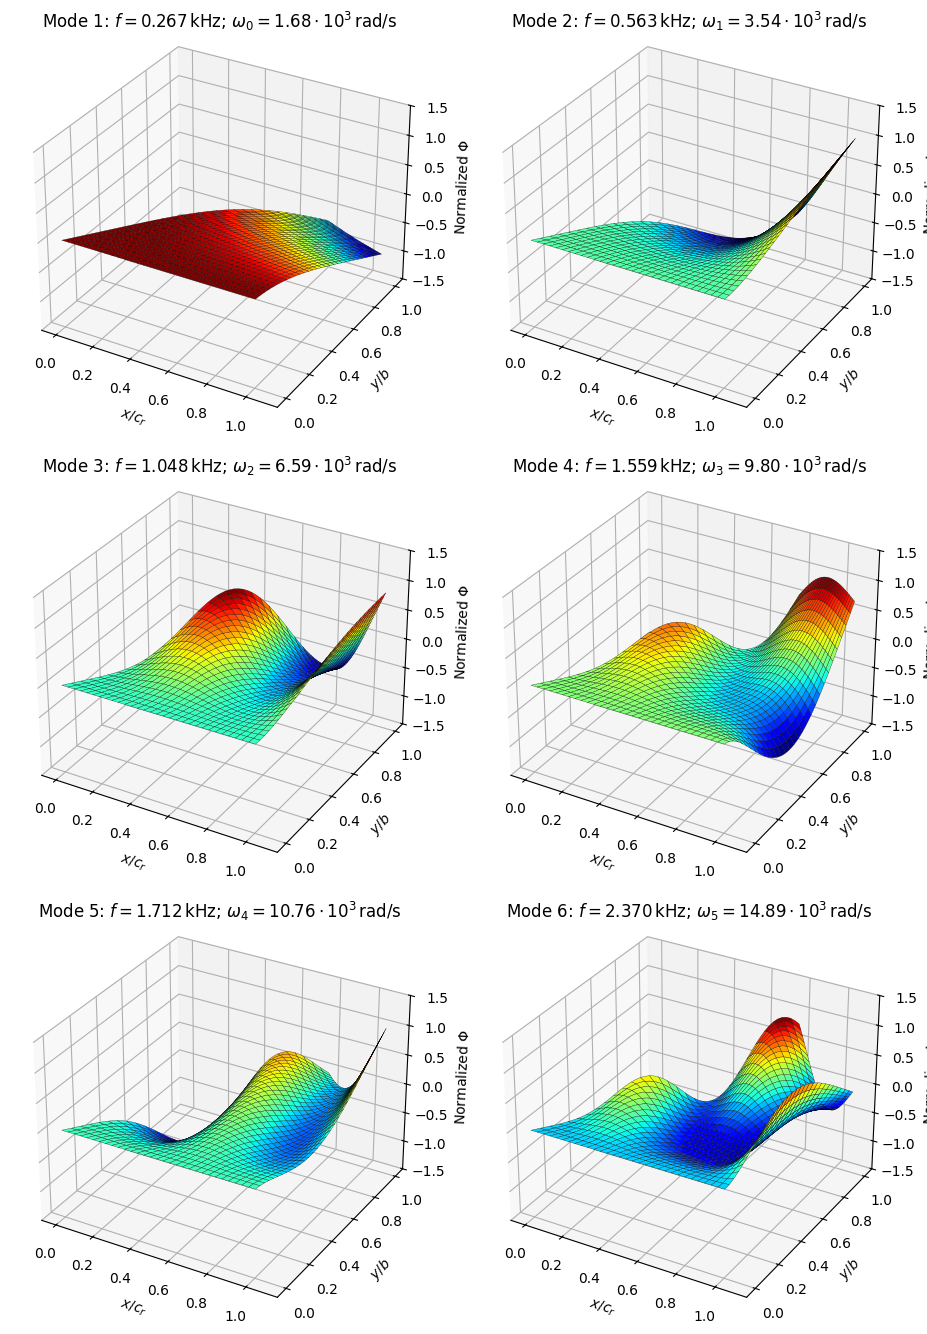

In [22]:
Phi = {}
omega = 2 * np.pi * freqs

X = nodes[:, 0].reshape((ny, nx))
Y = nodes[:, 1].reshape((ny, nx))
Z = nodes[:, 2].reshape((ny, nx))

n_rows = (modes + 1) // 2
fig = plt.figure(figsize=(10, 4.5 * n_rows))
gs = fig.add_gridspec(n_rows, 2)

for i in range(modes):
    # Determine if this is the last item and odd
    is_last_odd = (i == modes - 1 and modes % 2 != 0)
    
    # If last and odd, span both columns; otherwise use standard grid
    if is_last_odd:
        ax = fig.add_subplot(gs[i // 2, :], projection='3d')
    else:
        ax = fig.add_subplot(gs[i // 2, i % 2], projection='3d')

    W = vecs[2::5, i].reshape((ny, nx))
    Phi[i] = W
    W_norm = W / np.max(np.abs(W))

    ax.plot_surface(X/cr, Y/b, Z/cr + W_norm, cmap='jet', edgecolor='k', linewidth=0.2)
    ax.set_title(f'Mode {i+1}: $f={freqs[i]/1e3:.3f}\\,$kHz; $\\omega_{i}={omega[i]/1e3:.2f} \\cdot 10^3 \\,$rad/s', y=1.03)
    ax.set_zlim(-1.5, 1.5)
    
    # Hide axis labels for compactness if preferred
    ax.set_xlabel('$x/c_r$'); ax.set_ylabel('$y/b$'); ax.set_zlabel('Normalized $\\Phi$')

plt.tight_layout()
plots['2-modes'] = plt.gcf()
update_pdf()
plt.show()

### Initialization of the Structural Model

$$\mathbf{M} \ddot{\mathbf{q}} + \mathbf{C} \dot{\mathbf{q}} + \mathbf{K} \mathbf{q} = \mathbf{\mathbf{Q}}\left(\mathbf{q},\dot{\mathbf{q}}\right)$$

In [34]:
L = 0.0065       # K/m
T0 = 288.15      # K
P0 = 101325      # Pa
g0 = 9.80665     # m/s^2
Ma = 0.0289644   # kg/mol
R = 8.31447      # J/(mol*K)
gamma = 1.4
zeta = 0.01

M_modal = np.eye(len(omega))
K_modal = np.diag(omega**2)
C_modal = np.diag(2 * zeta * omega)

### Piston Theory

The exact isentropic piston relation expresses the local surface pressure as a function of the normal velocity perturbation $v_n$:
$$\frac{p}{p_\infty} = \left(1 + \frac{\gamma-1}{2}\frac{v_n}{a_\infty}\right)^{\frac{2\gamma}{\gamma-1}}$$
Expanding as a binomial series yields piston theory at arbitrary order $N$:
$$p = p_\infty \sum_{n=0}^{N} c_n \left(\frac{v_n}{a_\infty}\right)^n, \qquad c_n = \frac{1}{n!}\prod_{k=0}^{n-1}\left(\frac{2\gamma}{\gamma-1} - k\right)\left(\frac{\gamma-1}{2}\right)^n$$

The series converges for $|v_n / a_\infty| < 2/(\gamma - 1)$, corresponding to the vacuum expansion limit. Truncating at $N = 1$ yields **linear piston theory**, which is used in this analysis. Higher-order terms introduce amplitude-dependent aerodynamic forces, making the flutter problem nonlinear (e.g., limit-cycle oscillations). Linear piston theory is valid for $M \gtrsim 1.5$ and $M \cdot (t/c) \ll 1$; for the present geometry this corresponds approximately to $M \lesssim 5\text{–}7$.

### Aerodynamic Generalized Forces

The generalized force is defined as the integral of the surface pressure perturbation $\Delta p(x, y, t) = p - p_\infty$ weighted by the mode shapes:
$$Q_i = \iint_S \Delta p(x, y, t) \, \phi_i^n(x, y) \, dA$$
For a cambered surface with slope $\partial z_c/\partial x$, the velocity perturbation is projected onto the local surface normal. Defining $\cos\theta = 1/\sqrt{1 + \left(\partial z_c/\partial x\right)^2}$, the normal-projected mode shape is $\phi_i^n = \phi_i \cos\theta$, and the modal expansion of the normal displacement is $w^n(x, y, t) = \sum_j q_j(t) \phi_j^n(x, y)$. The normal velocity perturbation is:
$$v_n = \frac{\partial w^n}{\partial t} + V_\infty \frac{\partial w^n}{\partial x} = \sum_j \left( \dot{q}_j \phi_j^n + V_\infty q_j \, \partial_x \phi_j^n \right)$$
For a flat plate ($z_c = 0$), $\cos\theta = 1$ and $\phi_i^n = \phi_i$, recovering the standard formulation.

In [35]:
dz_camber_dx = np.zeros_like(Z)
for row in range(ny):
    dz_camber_dx[row, :] = np.gradient(Z[row, :], X[row, :])

cos_theta = 1 / np.sqrt(1 + dz_camber_dx**2)

Phi_n = {}
dPhi_dx = {}
for i in range(modes):
    Phi_n[i] = Phi[i] * cos_theta
    dPhi_dx[i] = np.zeros_like(Phi_n[i])
    for row in range(ny):
        dPhi_dx[i][row, :] = np.gradient(Phi_n[i][row, :], X[row, :])

def area_integral(F):
    x_integ = simpson(F, x=X, axis=1)
    return simpson(x_integ, x=Y[:, 0])

# Stack mode fields into 3D arrays of shape (modes, ny, nx) for clean broadcasting
Phi_n_stack  = np.stack([Phi_n[i]   for i in range(modes)], axis=0)
dPhi_x_stack = np.stack([dPhi_dx[i] for i in range(modes)], axis=0)

In [36]:
ATM_layer = np.array([
    [0, -6.5e-3, 288.15, 101325.0],
    [11000, 0.0, 216.65, 22632.1],
    [20000, 1.0e-3, 216.65, 5474.89],
    [32000, 2.8e-3, 228.65, 868.02],
    [47000, 0.0, 270.65, 110.91],
    [51000, -2.8e-3, 270.65, 66.94],
    [71000, -2.0e-3, 214.65, 3.96],
    [84852, 0.0, 186.95, 0.373]
])

def get_layer(h):
    h_arr = np.asarray(h)
    idx = np.searchsorted(ATM_layer[:, 0], np.atleast_1d(h_arr), side='right') - 1
    return h_arr, ATM_layer[idx].T

def a_sound(h):
    h_arr, (hb, L, Tb, _) = get_layer(h)
    a = np.sqrt(gamma * T0 * (Tb + L * (h_arr - hb)))
    return a.item() if h_arr.ndim == 0 else a

def rho_inf(h):
    h_arr, (hb, L, Tb, Pb) = get_layer(h)
    T = Tb + L * (h_arr - hb)
    
    P = np.where(
        L == 0,
        Pb * np.exp(-g0 * Ma / R * (h_arr - hb) / Tb),
        Pb * (T / Tb) ** (-g0 * Ma / R / np.where(L == 0, 1.0, L))
    )
    
    rho = (P * Ma) / (R * T)
    return rho.item() if h_arr.ndim == 0 else rho

### Third-Order Piston Theory

Truncating the isentropic expansion at third order and applying Van Dyke's second-order correction (which replaces $a_\infty \to a_\infty\sqrt{\beta}$ with $\beta = \sqrt{M^2-1}$ in the linear term) yields:
$$\Delta p = \frac{\rho_\infty V_\infty}{\beta} v_n + p_\infty \left[ c_2 \left(\frac{v_n}{a_\infty}\right)^{\!2} + c_3 \left(\frac{v_n}{a_\infty}\right)^{\!3} \right]$$
with coefficients
$$c_2 = \frac{\gamma(\gamma+1)}{4}, \qquad c_3 = \frac{\gamma(\gamma+1)}{12}$$
The generalized force decomposes by order, $Q_i = Q_i^{(1)} + Q_i^{(2)} + Q_i^{(3)}$.

#### Linear contribution.
Substituting the modal expansion of $v_n$ gives:
$$Q_i^{(1)} = \sum_j \left[ C_{a,ij}\,\dot{q}_j + K_{a,ij}\,q_j \right]$$
$$\mathbf{C}_a = \frac{\rho_\infty V_\infty}{\beta}\,\mathbf{A}_C, \qquad A_{C,ij} = \iint_S \phi_i^n \phi_j^n \, dA$$
$$\mathbf{K}_a = \frac{\rho_\infty V_\infty^2}{\beta}\,\mathbf{A}_K, \qquad A_{K,ij} = \iint_S \phi_i^n \, \partial_x \phi_j^n \, dA$$

In [37]:
def A_Kij(i, j):
    x_integ = simpson(Phi_n[i] * dPhi_dx[j], x=X, axis=1)
    y_integ = simpson(x_integ, x=Y[:, 0])
    return y_integ

def A_Cij(i, j):
    x_integ = simpson(Phi_n[i] * Phi_n[j], x=X, axis=1)
    y_integ = simpson(x_integ, x=Y[:, 0])
    return y_integ

A_K = np.zeros((modes, modes))
A_C = np.zeros((modes, modes))
for i in range(modes):
    for j in range(modes):
        A_K[i, j] = A_Kij(i, j)
        A_C[i, j] = A_Cij(i, j)

In [38]:
h = 0
M_range = np.linspace(1.5, 3.5, res_fl)
sigma_modes = []
omega_modes = []

LHS = np.block([
    [np.eye(modes), np.zeros((modes, modes))],
    [np.zeros((modes, modes)), M_modal]
])

for M in M_range:
    U = a_sound(h) * M

    VanDyke = M**2 / Beta(M)**2
    
    Ka = - (2 * rho_inf(h) * U**2 / Beta(M)) * A_K
    Ca = - (2 * rho_inf(h) * U / Beta(M)) * A_C * VanDyke
    
    RHS = np.block([
        [np.zeros((modes, modes)), np.eye(modes)],
        [-(K_modal - Ka), -(C_modal - Ca)]
    ])
    
    vals, _ = eig(RHS, LHS)
    
    pos = vals[np.imag(vals) >= 0]
    pos = pos[np.argsort(np.imag(pos))]
    
    sigma_modes.append(np.real(pos))
    omega_modes.append(np.imag(pos))

sigma_modes = np.array(sigma_modes)
omega_modes = np.array(omega_modes)

Updated plots.pdf with 3 page(s).


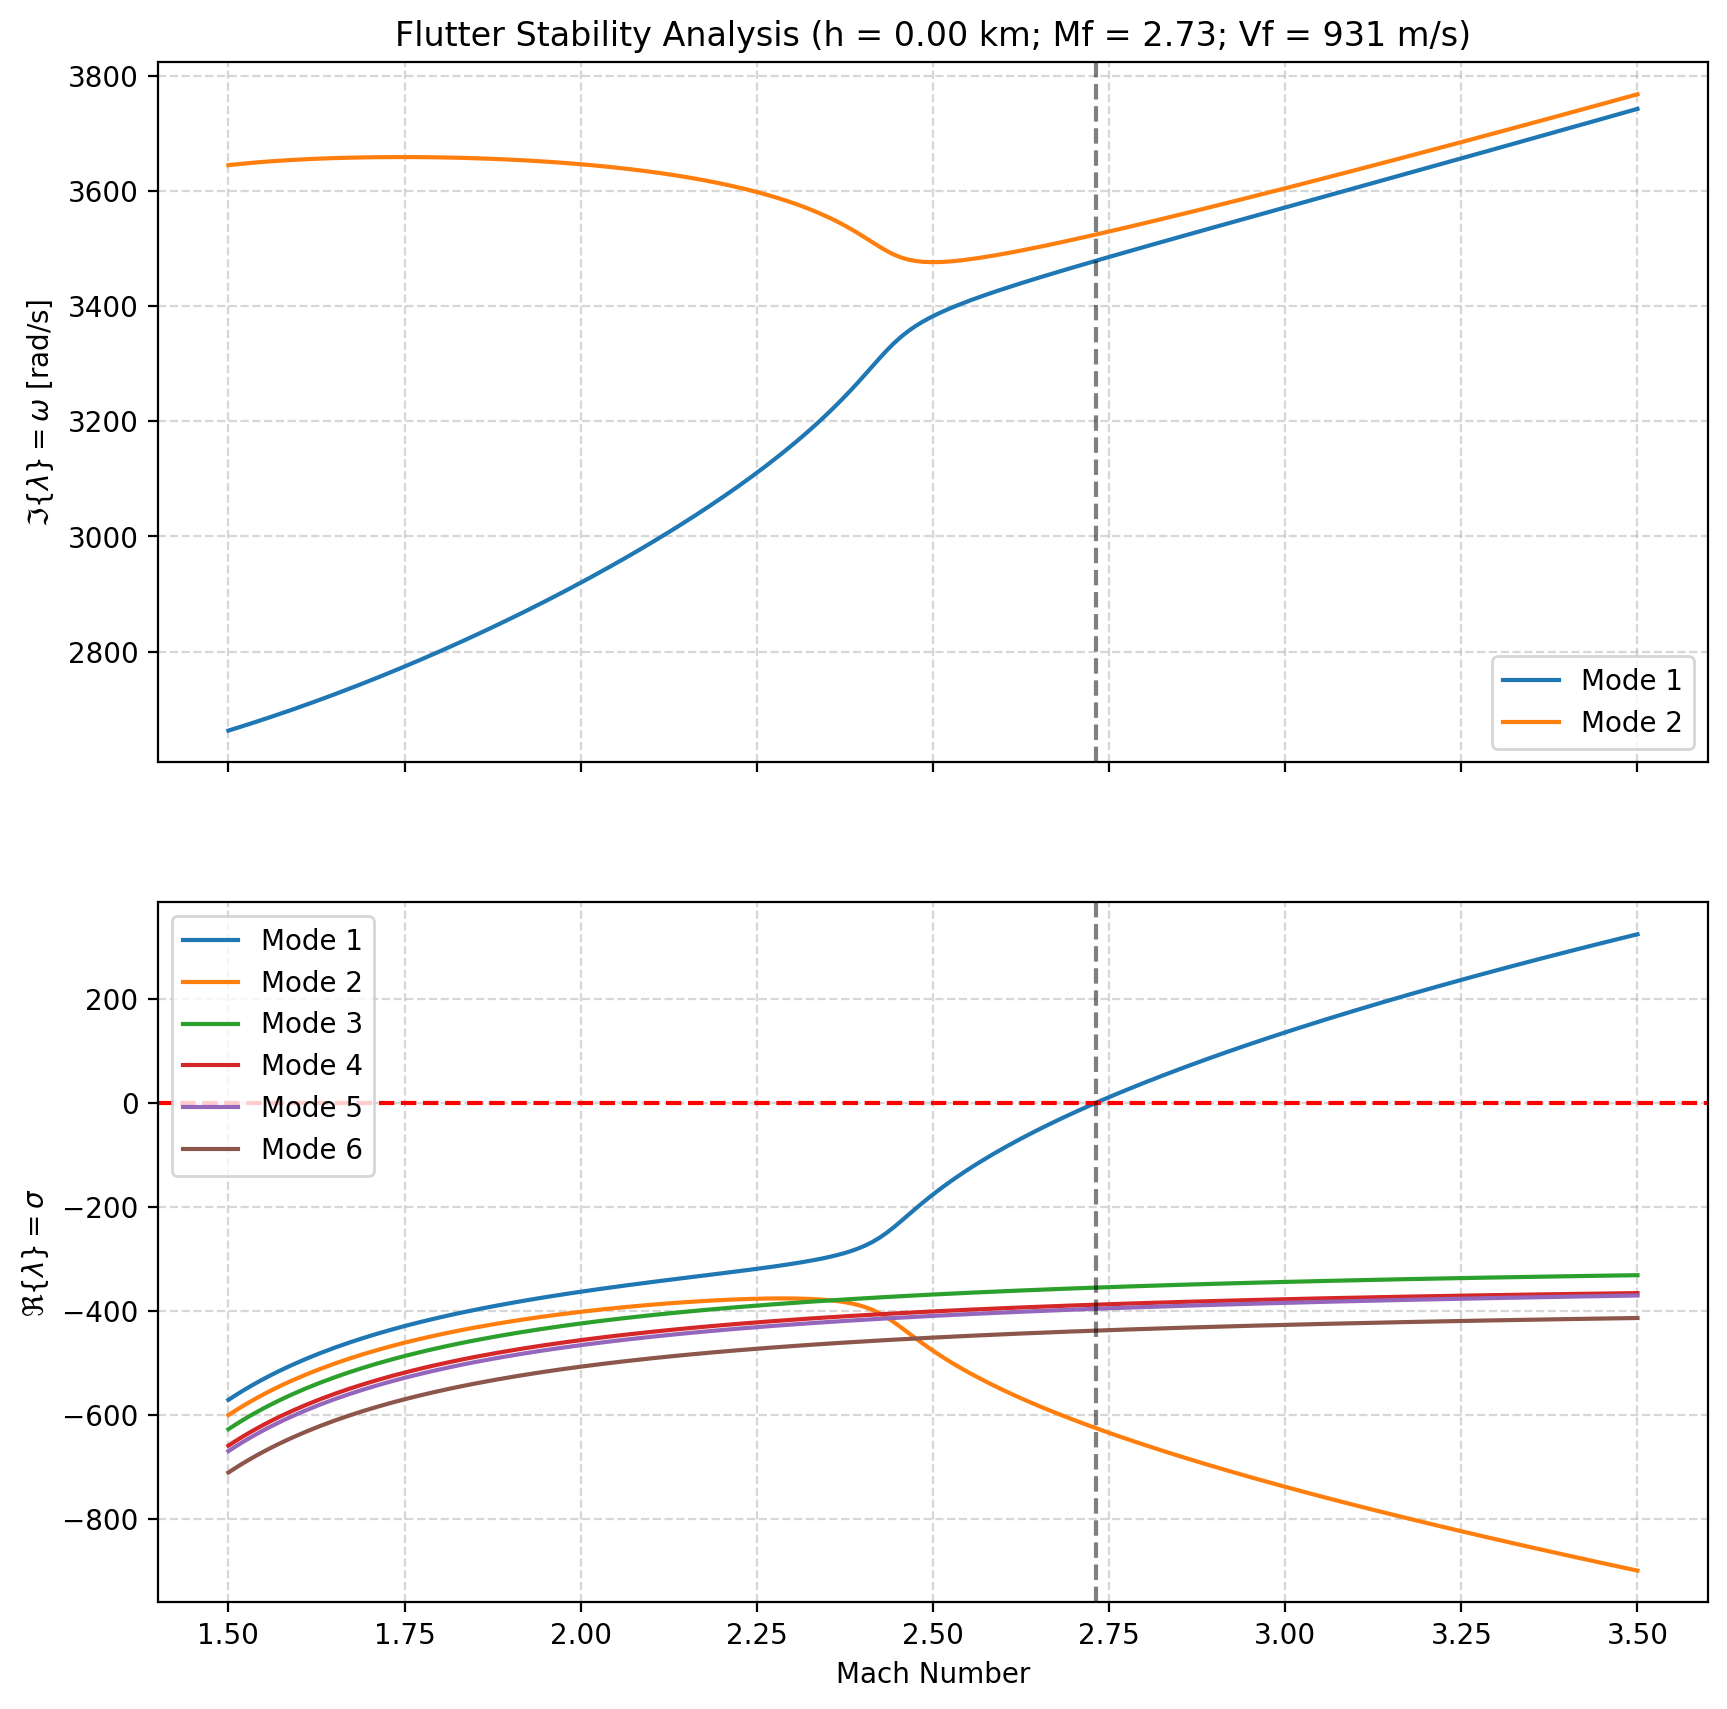

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), dpi=200, sharex=True)

# find flutter Mach
sigma_max = np.max(sigma_modes, axis=1)
M_flutter = None
ax1.set_title(f'Flutter Stability Analysis (No flutter speed found in the range M ∈ [{M_range[0]}, {M_range[-1]}] at h = {h} m)')
for i in range(len(sigma_max) - 1):
    if sigma_max[i] < 0 and sigma_max[i+1] > 0:
        M_flutter = M_range[i] + (0 - sigma_max[i]) / (sigma_max[i+1] - sigma_max[i]) * (M_range[i+1] - M_range[i])
        ax1.set_title(f'Flutter Stability Analysis (h = {h/1e3:.2f} km; Mf = {M_flutter:.2f}; Vf = {M_flutter * a_sound(0):.0f} m/s)')
        break

# top: frequency coalescence
for j in range(2):
    ax1.plot(M_range, omega_modes[:, j], label=f'Mode {j+1}')
if M_flutter:
    ax1.axvline(M_flutter, color='k', ls='--', alpha=0.5)
ax1.set_ylabel('$\\Im\\{\\lambda\\}=\\omega$ [rad/s]')
ax1.grid(True, alpha=0.5, ls='--')
ax1.legend()

# bottom: damping
for j in range(sigma_modes.shape[1]):
    ax2.plot(M_range, sigma_modes[:, j], label=f'Mode {j+1}')
ax2.axhline(0, color='r', ls='--')
if M_flutter:
    ax2.axvline(M_flutter, color='k', ls='--', alpha=0.5)
ax2.set_xlabel('Mach Number')
ax2.set_ylabel('$\\Re\\{\\lambda\\}=\\sigma$')
ax2.grid(True, alpha=0.5, ls='--')
ax2.legend()

plots['3-flutter'] = plt.gcf()
update_pdf()
plt.show()

In [40]:
altitudes = np.linspace(0, 30000, res_alt)
M_range = np.linspace(1.5, 8, res_alt)
V_flutter = []
eig_errors = 0

LHS = np.block([
    [np.eye(modes), np.zeros((modes, modes))],
    [np.zeros((modes, modes)), M_modal]
])

for h in altitudes:
    a_h = a_sound(h)
    rho_h = rho_inf(h)
    
    M_f = None
    prev_sigma_max = None
    
    for M in M_range:
        U = a_h * M
        VanDyke = M**2 / Beta(M)**2
        
        Ka = - (2 * rho_h * U**2 / Beta(M)) * A_K
        Ca = - (2 * rho_h * U / Beta(M)) * A_C * VanDyke
        
        RHS = np.block([
            [np.zeros((modes, modes)), np.eye(modes)],
            [-(K_modal - Ka), -(C_modal - Ca)]
        ])
        
        try:
            vals, _ = eig(RHS, LHS)
        except np.linalg.LinAlgError:
            eig_errors += 1
            prev_sigma_max = None
            continue
        
        curr_sigma_max = np.max(np.real(vals))
        
        if prev_sigma_max is not None and prev_sigma_max < 0 and curr_sigma_max > 0:
            M_prev = M - (M_range[1] - M_range[0])
            M_f = M_prev + (0 - prev_sigma_max) / (curr_sigma_max - prev_sigma_max) * (M - M_prev)
            break
        
        prev_sigma_max = curr_sigma_max
    
    V_flutter.append(M_f * a_h if M_f else np.nan)

V_flutter = np.array(V_flutter)

if eig_errors > 0:
    print(f"Warning: {eig_errors} eigenvalue solve(s) did not converge and were skipped.")

#### Analytical Solution

$$M_{f}\left(h\right)=\sqrt{\frac{G\cdot\pi}{12\cdot\epsilon\cdot\rho \cdot a^2}\cdot\frac{A+2}{A^{3}}\cdot\frac{t^{3}}{c_{r}^{2}\left(c_{t}+c_{r}\right)}}$$

$$\epsilon=\frac{c_{r}^{2}+c_{r}c_{t}+c_{r}b+c_{t}^{2}+2c_{t}b}{3c_{r}\left(c_{r}+c_{t}\right)}-0.25$$

In [41]:
A = 2 * b / (cr + ct)
alpha_air = (g0 * Ma) / (L * R)
eps = (cr**2 + cr*ct + cr*b + ct**2 + 2*ct*b) / (3*cr*(cr + ct)) - 0.25

def flutter_analytical(h):
    Vf_mach = np.sqrt(G * np.pi / (12 * eps * rho_inf(h) * a_sound(h)**2) * (A + 2) / A**3 * t**3 / (cr**2 * (ct + cr)))
    return Vf_mach

Updated plots.pdf with 4 page(s).


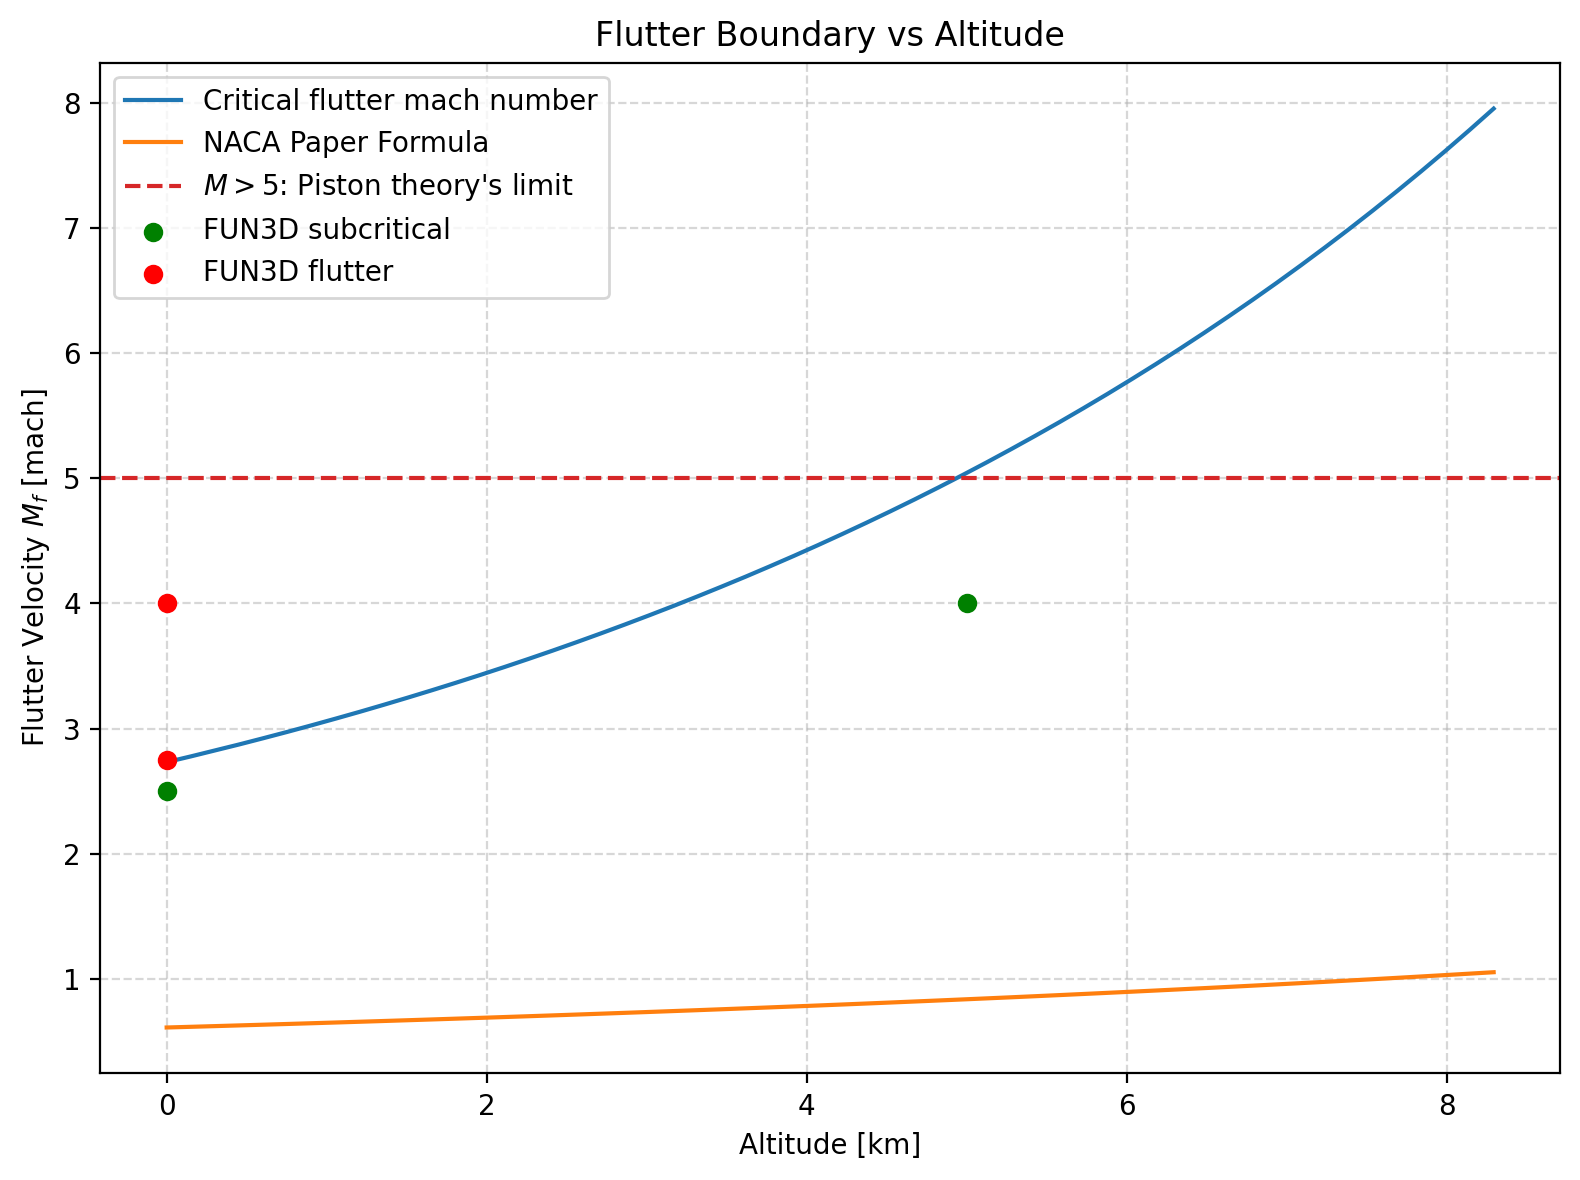

In [ ]:
plt.figure(figsize=(8, 6), dpi=200)

fun3d_flutter = []

has_numerical = np.any(~np.isnan(V_flutter))

if has_numerical:
    num_len = len(V_flutter[~np.isnan(V_flutter)])
    plt.plot(altitudes / 1000, V_flutter / a_sound(altitudes), label='Critical flutter mach number', color='C0')
    alt_ana = altitudes[:num_len]
else:
    alt_ana = altitudes

plt.plot(alt_ana / 1000, flutter_analytical(alt_ana), label='NACA Paper Formula', color='C1')
plt.axhline(5, ls='--', color='C3', label='$M>5$: Piston theory\'s limit')

plt.title('Flutter Boundary vs Altitude' + ('' if has_numerical else ' (no numerical convergence)'))
plt.ylabel('Flutter Velocity $M_f$ [mach]')
plt.xlabel('Altitude [km]')

plt.legend()
plt.grid(True, alpha=0.5, ls='--')
plots['4-flutter-envelope'] = plt.gcf()
update_pdf()
plt.tight_layout()
plt.show()

if not has_numerical:
    print("No numerical flutter speed found: eigenvalue solver did not converge across the Mach range.")